# Multiple Linear Regression — Data Exploration

Exploratory Data Analysis of the Advertising dataset for
Multiple Linear Regression.

### Objective

Explore the relationships between advertising expenditure
(TV, Radio, Newspaper) and Sales before building the
Multiple Linear Regression model.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.columns = ["Id", "TV", "Radio", "Newspaper", "Sales"]

df.head()

,Id,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df = df.drop(columns=["Id"])

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
df.shape

(200, 4)

In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [10]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [14]:
X = df.drop(columns=["Sales"])
y = df["Sales"]

In [17]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [18]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [19]:
print("X Shape: ", X.shape)
print("y Shape: ", y.shape)

X Shape:  (200, 3)
y Shape:  (200,)


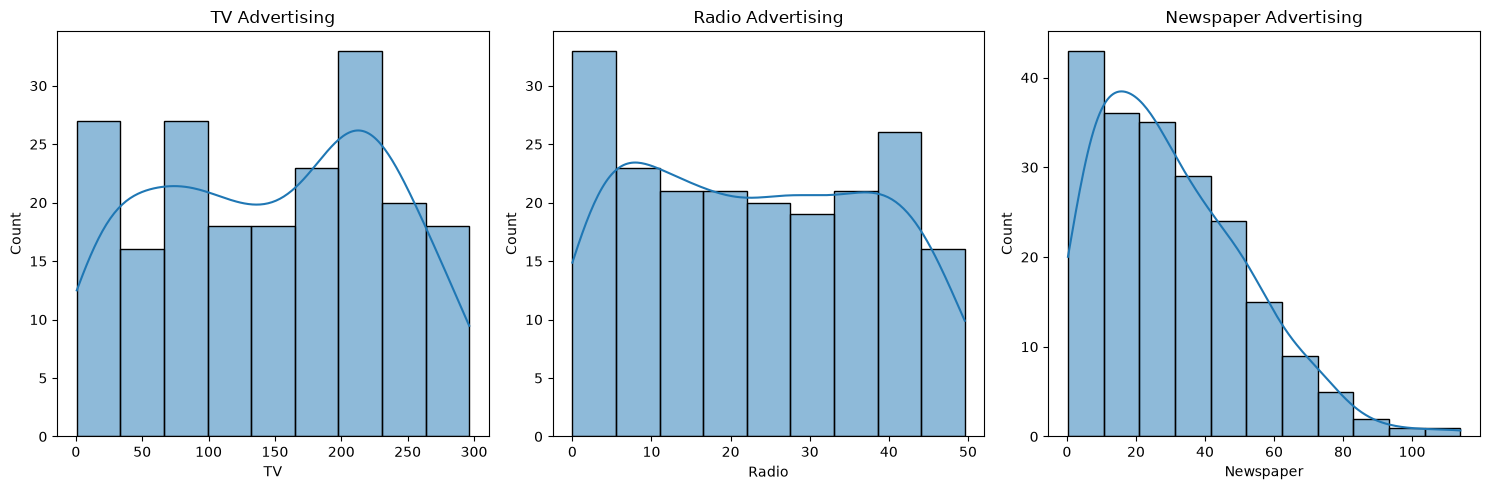

In [21]:
# Checking the distribution of each column of X
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df["TV"], kde=True, ax=axes[0])
axes[0].set_title("TV Advertising")

sns.histplot(df["Radio"], kde=True, ax=axes[1])
axes[1].set_title("Radio Advertising")

sns.histplot(df["Newspaper"], kde=True, ax=axes[2])
axes[2].set_title("Newspaper Advertising")

plt.tight_layout()
plt.show()

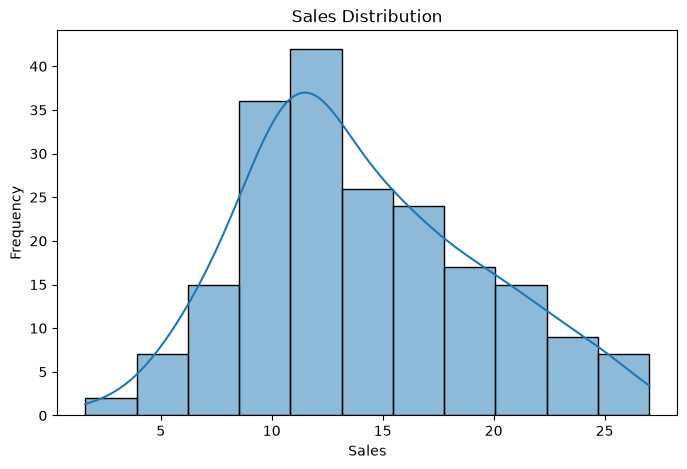

In [23]:
# Checking the dsitribution of y column
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

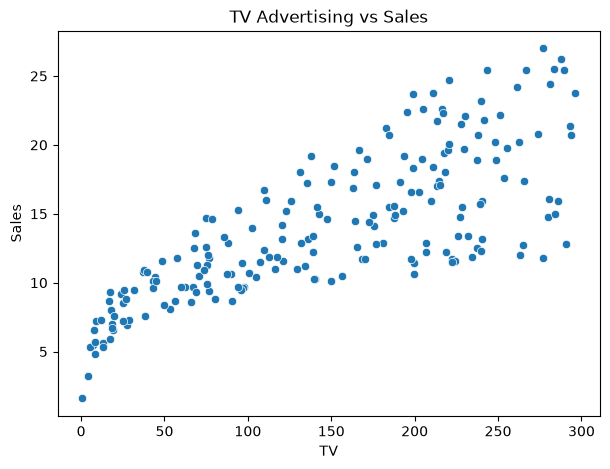

In [24]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("TV Advertising vs Sales")

plt.show()

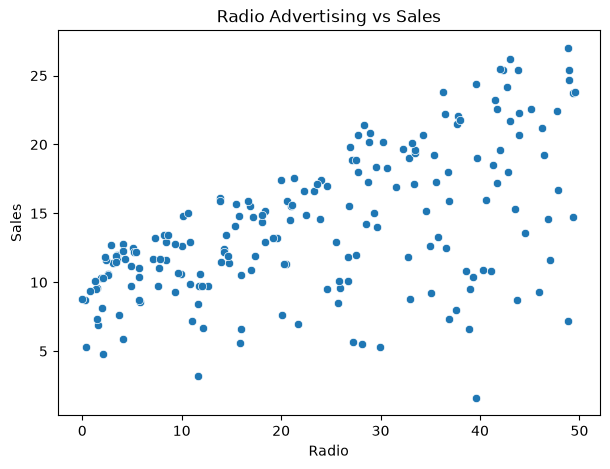

In [25]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Radio Advertising vs Sales")

plt.show()

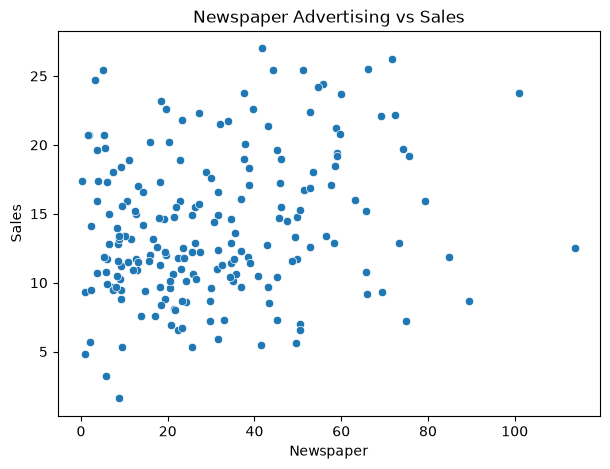

In [26]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Newspaper Advertising vs Sales")

plt.show()

In [27]:
correlation_matrix = df.corr()

correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


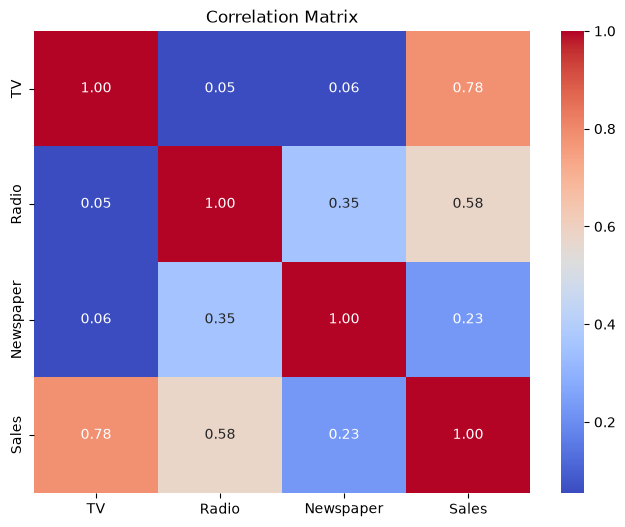

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

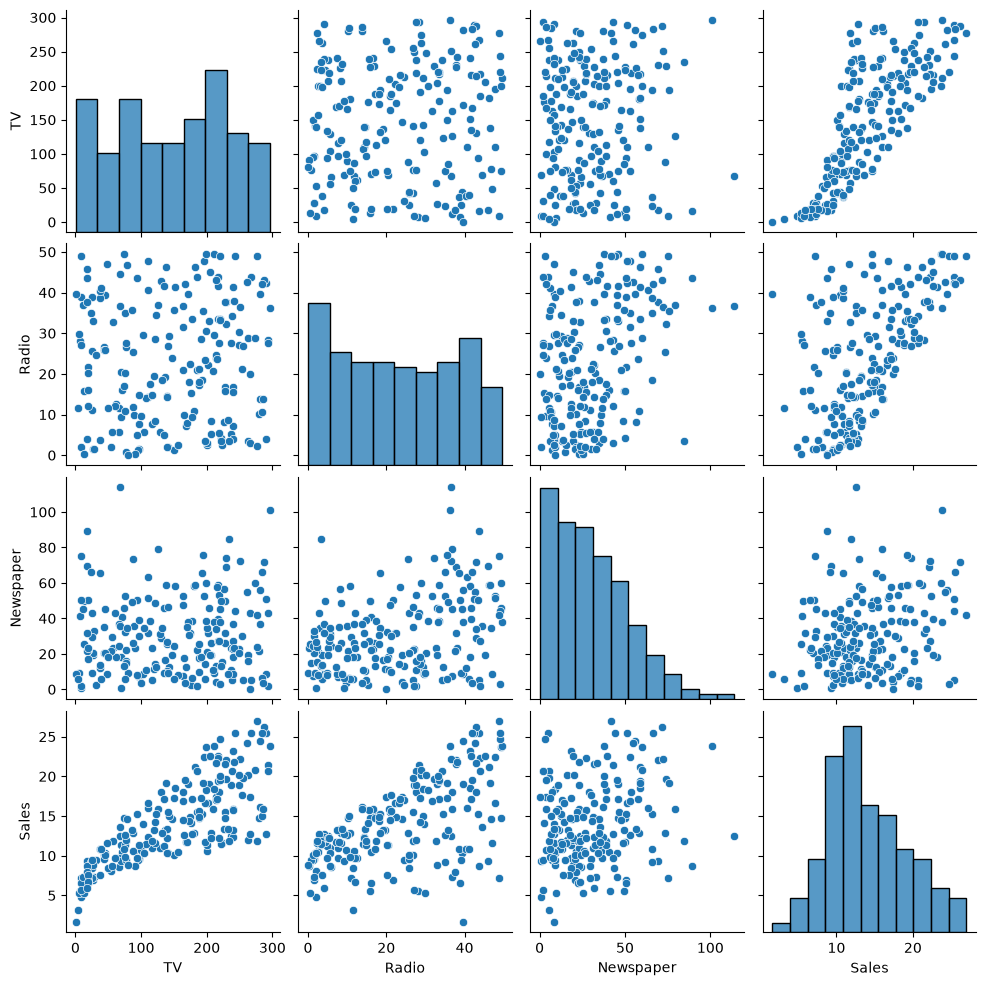

In [29]:
sns.pairplot(df)

plt.show()

## Initial Observations

- The dataset contains 200 observations and 4 numerical variables.
- TV, Radio, and Newspaper represent advertising expenditure.
- Sales is the target variable.
- TV shows a strong linear relationship with Sales.
- Radio also shows a positive relationship with Sales.
- Newspaper shows a weaker relationship with Sales compared with TV and Radio.
- The predictors have different levels of correlation with Sales.
- The predictor-to-predictor correlations should also be considered when evaluating multicollinearity.